In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Train 


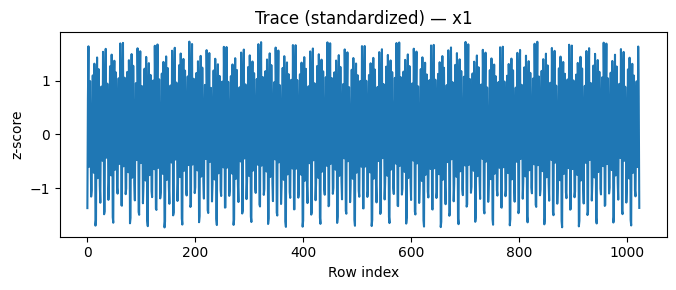

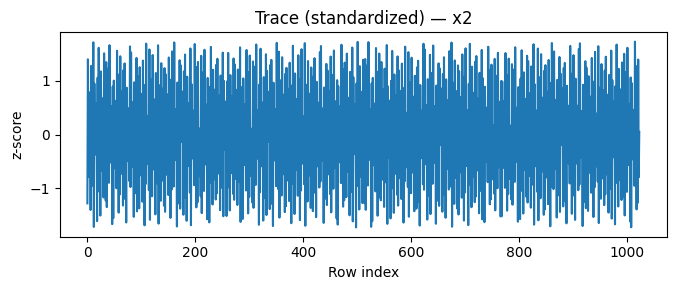

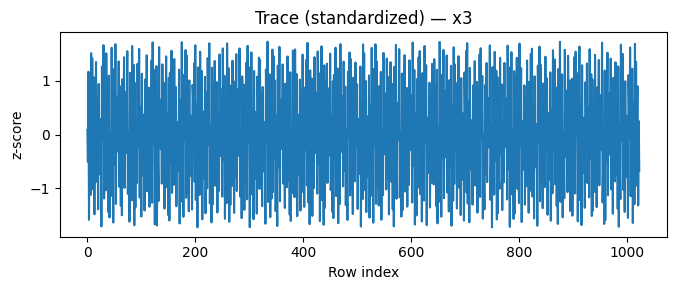

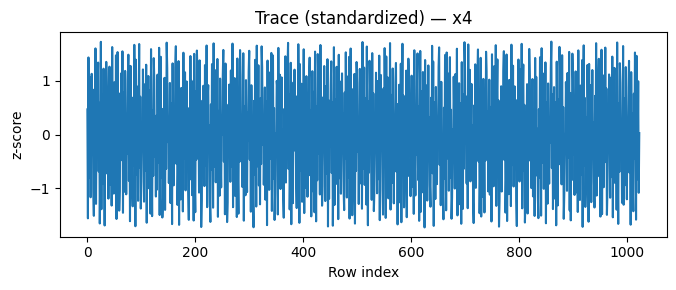

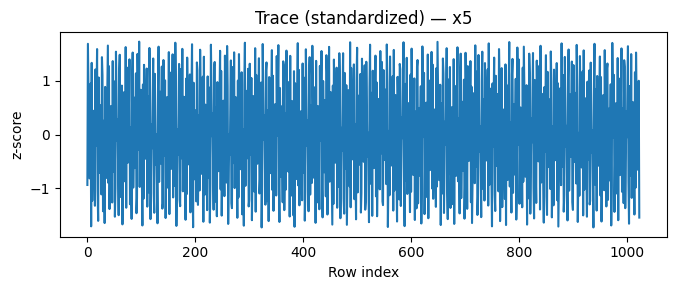

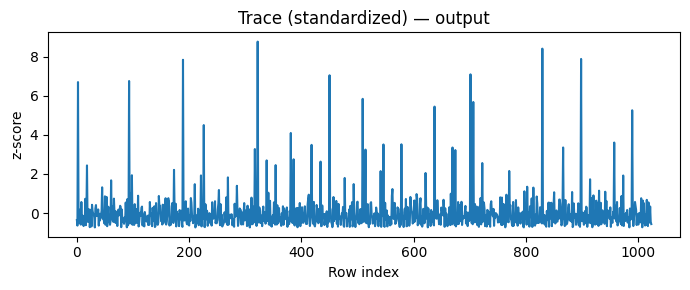

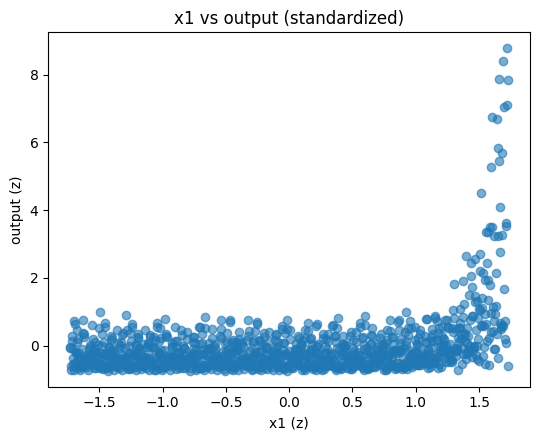

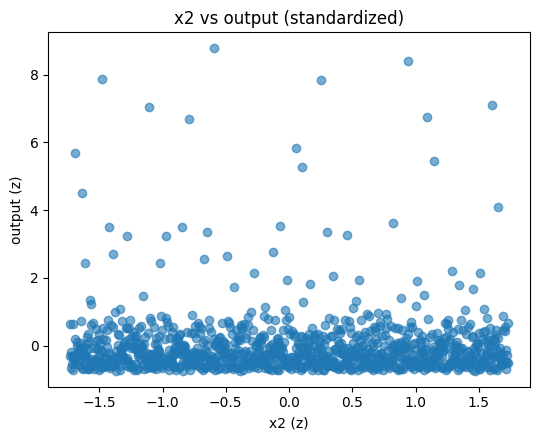

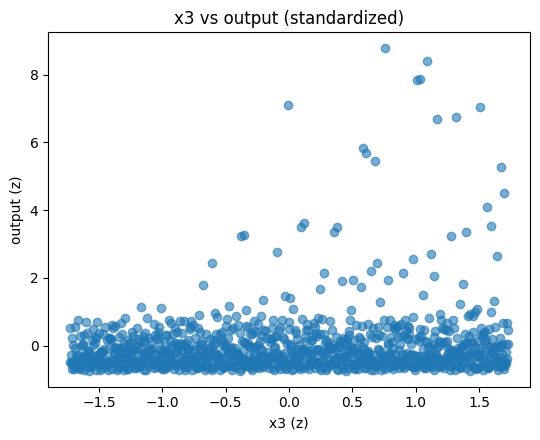

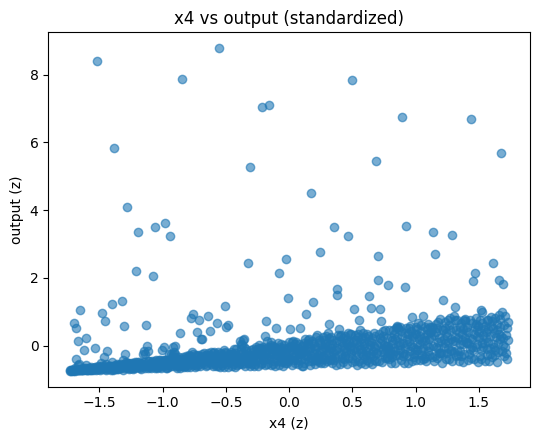

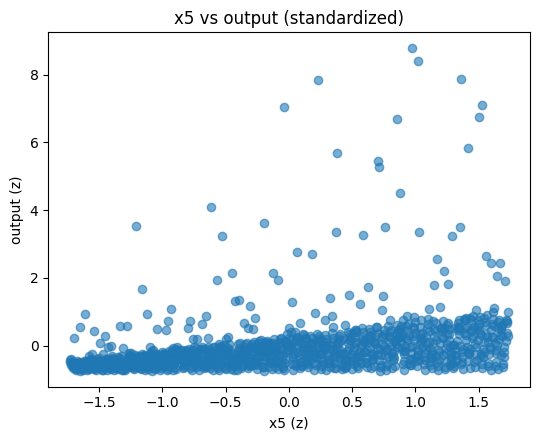

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

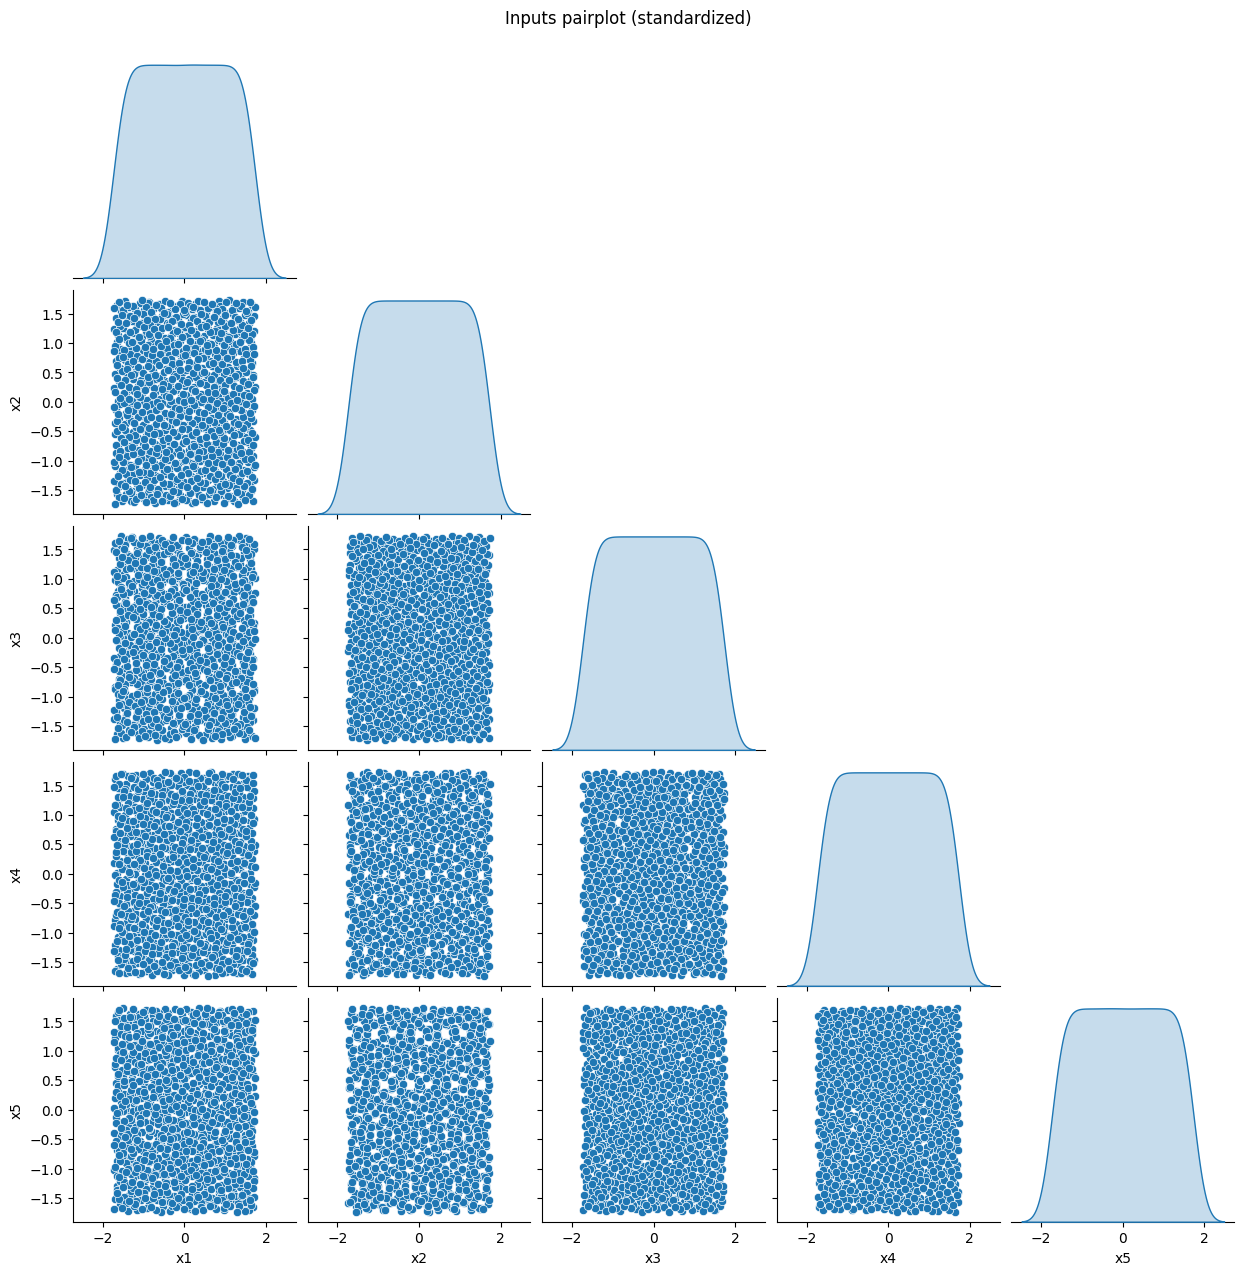

In [46]:


# ---- load ----
df = pd.read_csv("Completed_train_set_10_30_25.csv")

# first 5 = inputs, last = output
X = df.iloc[:, :5].astype(float)
y = df.iloc[:, -1].astype(float)

# ---- standardize (z-score, ddof=0 to match numpy) ----
Xz = (X - X.mean()) / X.std(ddof=0)
yz = (y - y.mean()) / y.std(ddof=0)

# ---- 1) trace plots of standardized columns (inputs + output) ----
for c in Xz.columns:
    plt.figure(figsize=(7, 3))
    plt.plot(Xz[c].values)
    plt.title(f"Trace (standardized) — {c}")
    plt.xlabel("Row index"); plt.ylabel("z-score")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(7, 3))
plt.plot(yz.values)
plt.title("Trace (standardized) — output")
plt.xlabel("Row index"); plt.ylabel("z-score")
plt.tight_layout(); plt.show()

# ---- 2) scatter: each input vs output (standardized) ----
for c in Xz.columns:
    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(Xz[c].values, yz.values, alpha=0.6)
    plt.xlabel(f"{c} (z)"); plt.ylabel("output (z)")
    plt.title(f"{c} vs output (standardized)")
    plt.tight_layout()
    plt.show()

# ---- 3) seaborn pairplot for input space (standardized) ----
sns.pairplot(Xz, corner=True, diag_kind="kde")
plt.suptitle("Inputs pairplot (standardized)", y=1.02)
plt.show()


## Test


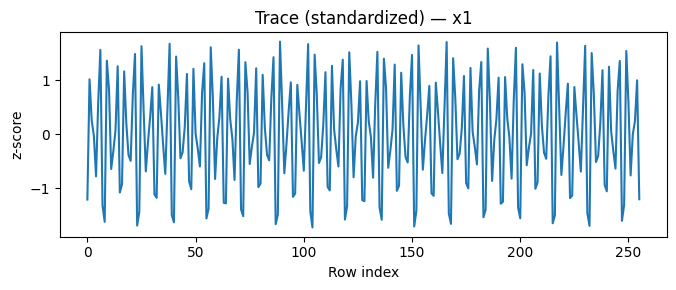

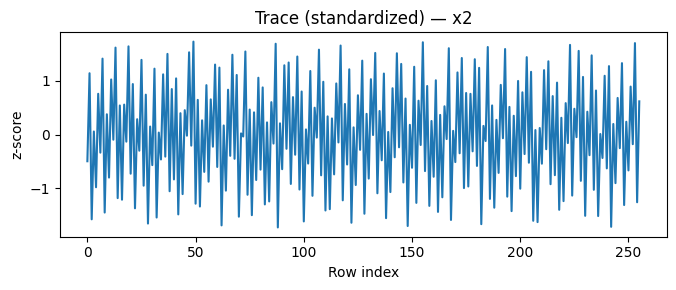

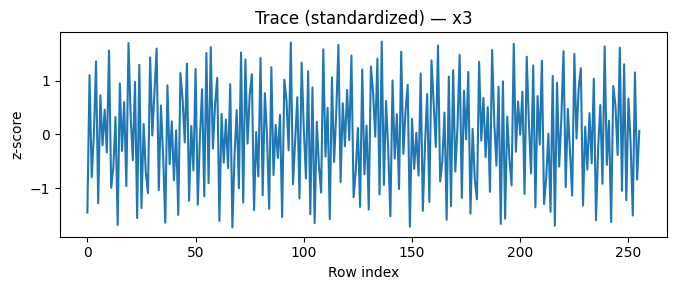

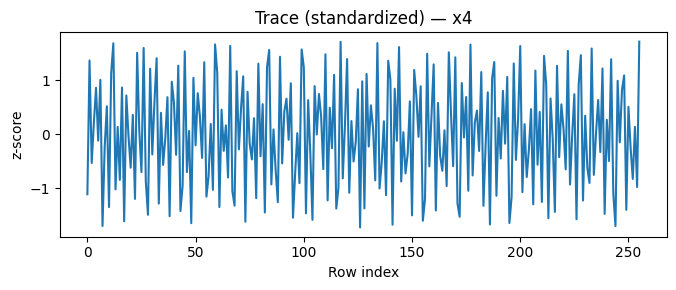

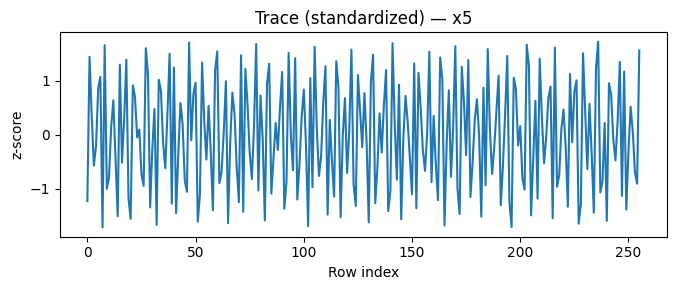

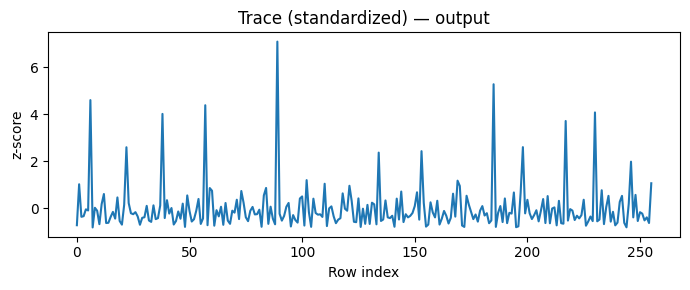

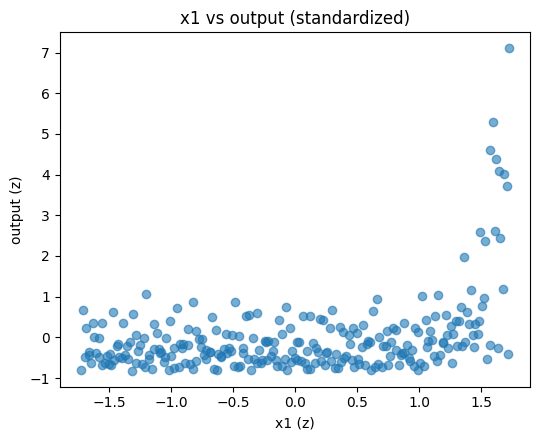

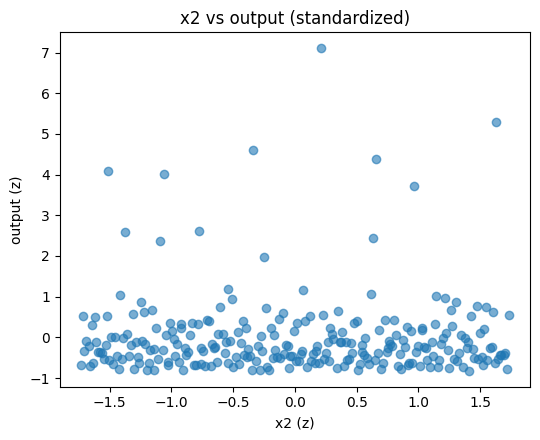

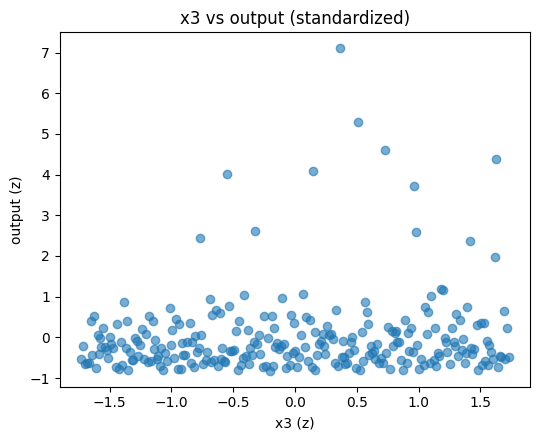

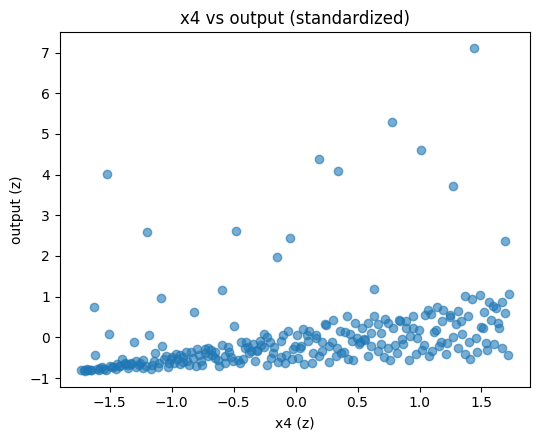

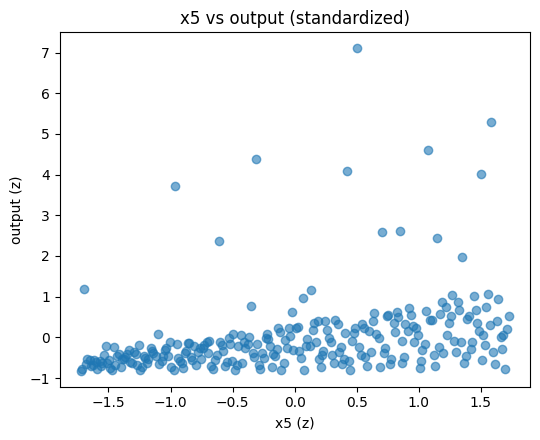

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

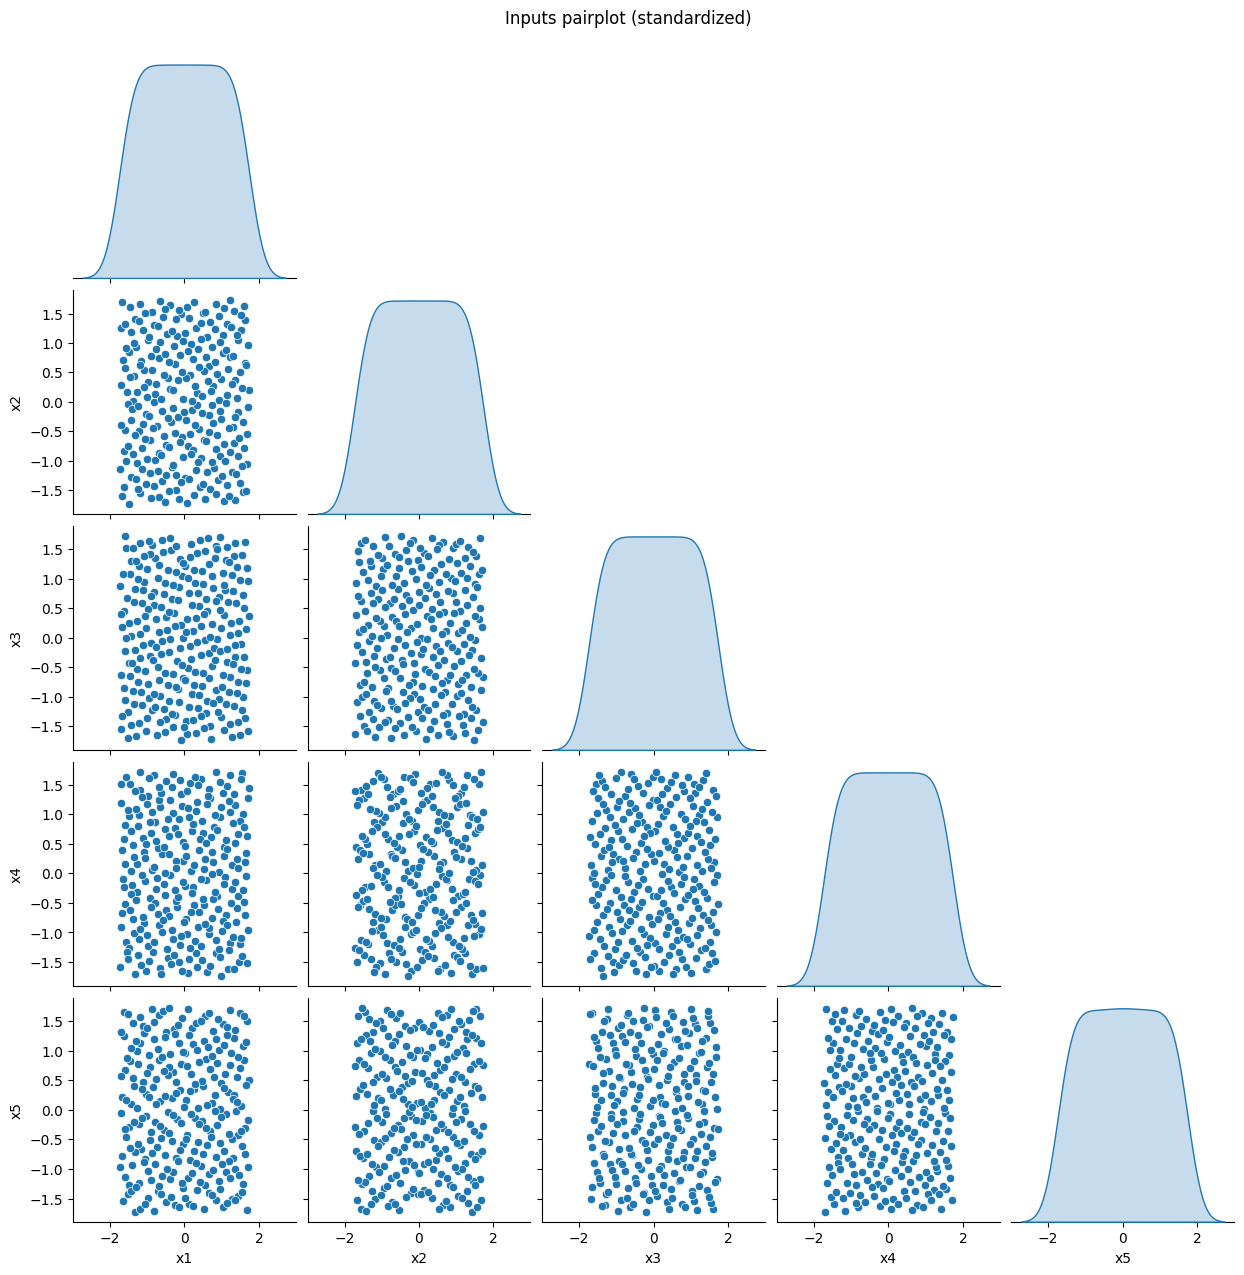

In [47]:


# ---- load ----
df = pd.read_csv("Completed_test_set_10_30_25.csv")

# first 5 = inputs, last = output
X = df.iloc[:, :5].astype(float)
y = df.iloc[:, -1].astype(float)

# ---- standardize (z-score, ddof=0 to match numpy) ----
Xz = (X - X.mean()) / X.std(ddof=0)
yz = (y - y.mean()) / y.std(ddof=0)

# ---- 1) trace plots of standardized columns (inputs + output) ----
for c in Xz.columns:
    plt.figure(figsize=(7, 3))
    plt.plot(Xz[c].values)
    plt.title(f"Trace (standardized) — {c}")
    plt.xlabel("Row index"); plt.ylabel("z-score")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(7, 3))
plt.plot(yz.values)
plt.title("Trace (standardized) — output")
plt.xlabel("Row index"); plt.ylabel("z-score")
plt.tight_layout(); plt.show()

# ---- 2) scatter: each input vs output (standardized) ----
for c in Xz.columns:
    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(Xz[c].values, yz.values, alpha=0.6)
    plt.xlabel(f"{c} (z)"); plt.ylabel("output (z)")
    plt.title(f"{c} vs output (standardized)")
    plt.tight_layout()
    plt.show()

# ---- 3) seaborn pairplot for input space (standardized) ----
sns.pairplot(Xz, corner=True, diag_kind="kde")
plt.suptitle("Inputs pairplot (standardized)", y=1.02)
plt.show()


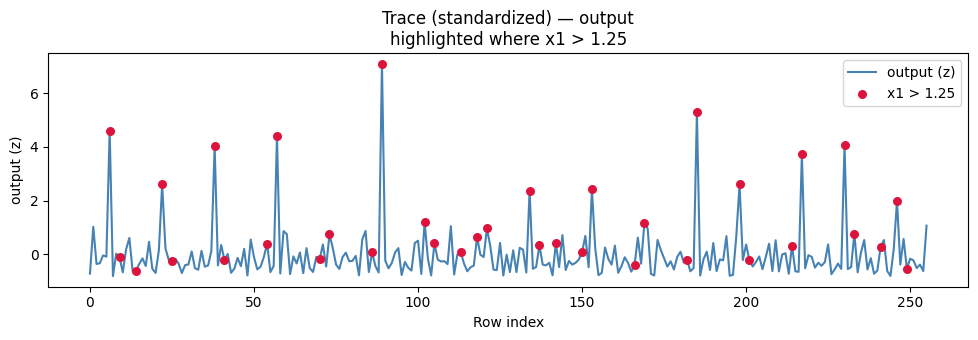

In [66]:
mask = Xz["x1"] > 1.25
indices = np.where(mask)[0]

# plot full trace
plt.figure(figsize=(10, 3.5))
plt.plot(yz, label="output (z)", color="steelblue")

# overlay highlighted points
plt.scatter(indices, yz[mask], color="crimson", s=30, label="x1 > 1.25", zorder=3)

plt.xlabel("Row index")
plt.ylabel("output (z)")
plt.title("Trace (standardized) — output\nhighlighted where x1 > 1.25")
plt.legend()
plt.tight_layout()
plt.show()

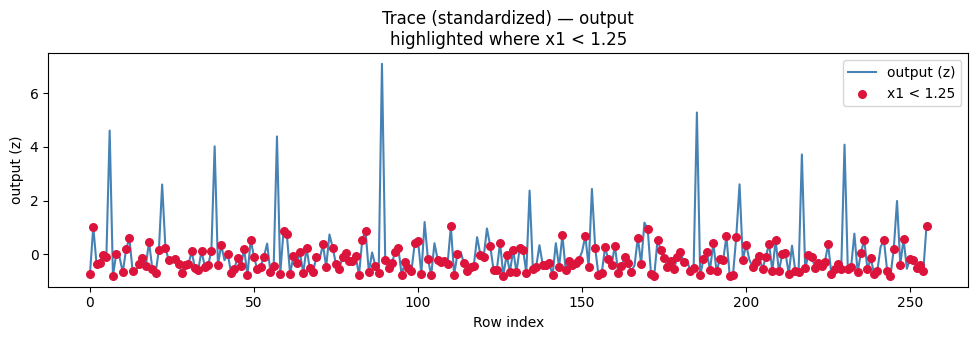

In [65]:
mask = Xz["x1"] < 1.25
indices = np.where(mask)[0]

# plot full trace
plt.figure(figsize=(10, 3.5))
plt.plot(yz, label="output (z)", color="steelblue")

# overlay highlighted points
plt.scatter(indices, yz[mask], color="crimson", s=30, label="x1 < 1.25", zorder=3)

plt.xlabel("Row index")
plt.ylabel("output (z)")
plt.title("Trace (standardized) — output\nhighlighted where x1 < 1.25")
plt.legend()
plt.tight_layout()
plt.show()

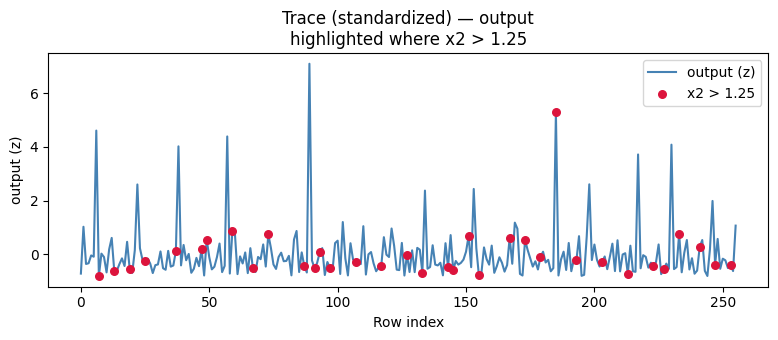

In [55]:
mask = Xz["x2"] > 1.25
indices = np.where(mask)[0]

# plot full trace
plt.figure(figsize=(10, 3.5))
plt.plot(yz, label="output (z)", color="steelblue")

# overlay highlighted points
plt.scatter(indices, yz[mask], color="crimson", s=30, label="x2 > 1.25", zorder=3)

plt.xlabel("Row index")
plt.ylabel("output (z)")
plt.title("Trace (standardized) — output\nhighlighted where x2 > 1.25")
plt.legend()
plt.tight_layout()
plt.show()

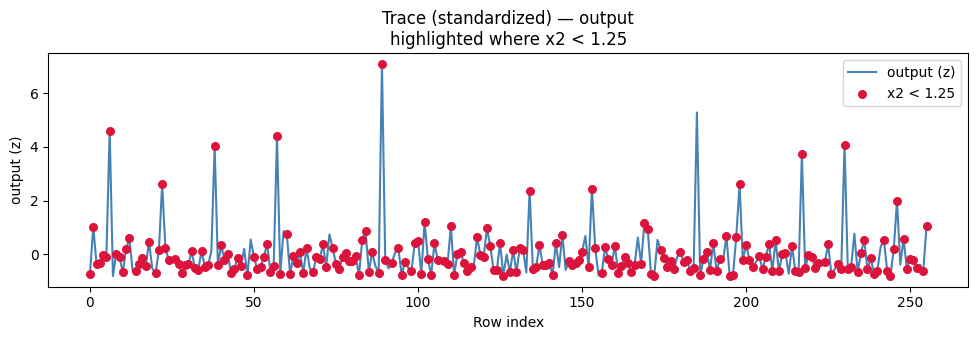

In [64]:
mask = Xz["x2"] < 1.25
indices = np.where(mask)[0]

# plot full trace
plt.figure(figsize=(10, 3.5))
plt.plot(yz,label="output (z)", color="steelblue")

# overlay highlighted points
plt.scatter(indices, yz[mask], color="crimson", s=30, label="x2 < 1.25", zorder=3)

plt.xlabel("Row index")
plt.ylabel("output (z)")
plt.title("Trace (standardized) — output\nhighlighted where x2 < 1.25")
plt.legend()
plt.tight_layout()
plt.show()

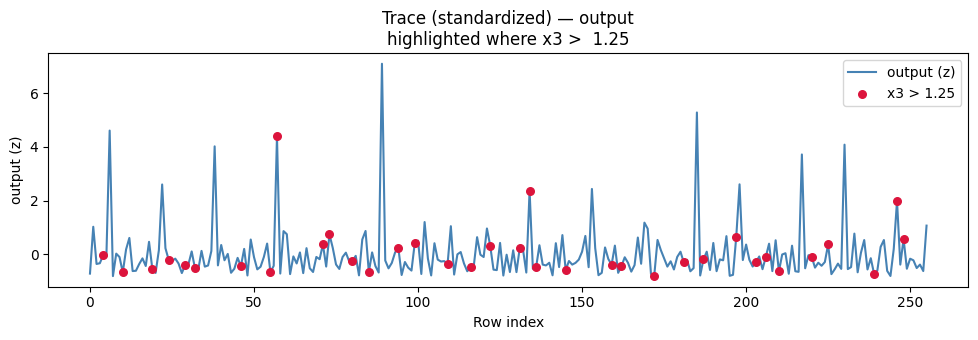

In [67]:
mask = Xz["x3"] > 1.25
indices = np.where(mask)[0]

# plot full trace
plt.figure(figsize=(10, 3.5))
plt.plot(yz,label="output (z)", color="steelblue")

# overlay highlighted points
plt.scatter(indices, yz[mask], color="crimson", s=30, label="x3 > 1.25", zorder=3)

plt.xlabel("Row index")
plt.ylabel("output (z)")
plt.title("Trace (standardized) — output\nhighlighted where x3 >  1.25")
plt.legend()
plt.tight_layout()
plt.show()

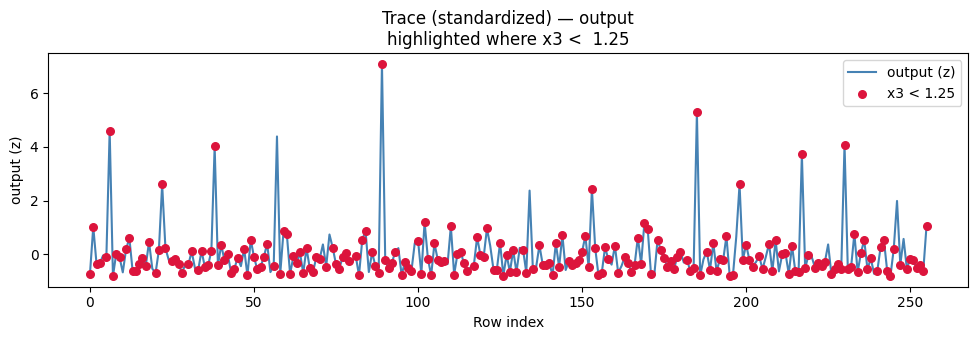

In [68]:
mask = Xz["x3"] < 1.25
indices = np.where(mask)[0]

# plot full trace
plt.figure(figsize=(10, 3.5))
plt.plot(yz,label="output (z)", color="steelblue")

# overlay highlighted points
plt.scatter(indices, yz[mask], color="crimson", s=30, label="x3 < 1.25", zorder=3)

plt.xlabel("Row index")
plt.ylabel("output (z)")
plt.title("Trace (standardized) — output\nhighlighted where x3 <  1.25")
plt.legend()
plt.tight_layout()
plt.show()

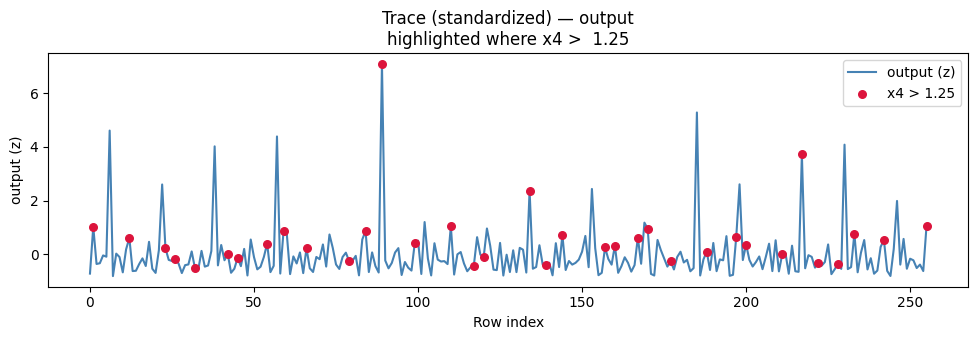

In [69]:
mask = Xz["x4"] > 1.25
indices = np.where(mask)[0]

# plot full trace
plt.figure(figsize=(10, 3.5))
plt.plot(yz,label="output (z)", color="steelblue")

# overlay highlighted points
plt.scatter(indices, yz[mask], color="crimson", s=30, label="x4 > 1.25", zorder=3)

plt.xlabel("Row index")
plt.ylabel("output (z)")
plt.title("Trace (standardized) — output\nhighlighted where x4 >  1.25")
plt.legend()
plt.tight_layout()
plt.show()

output    1.000000
x1        0.387490
x4        0.360560
x5        0.337267
x3        0.122747
x2       -0.013344
Name: output, dtype: float64


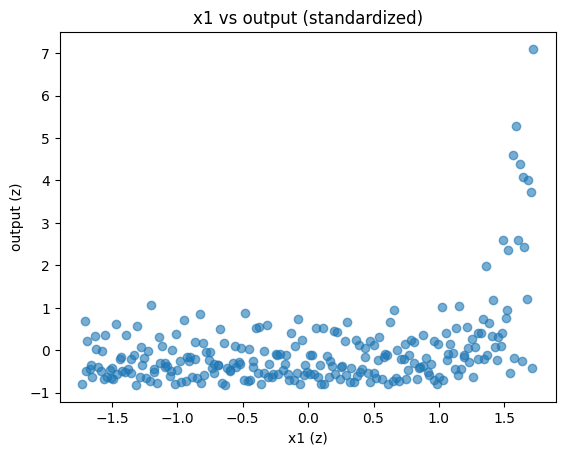

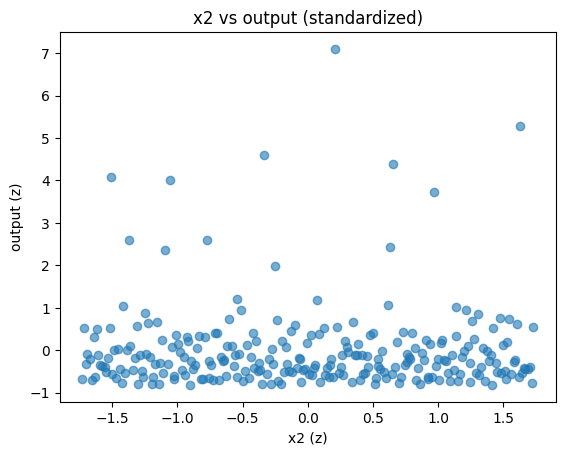

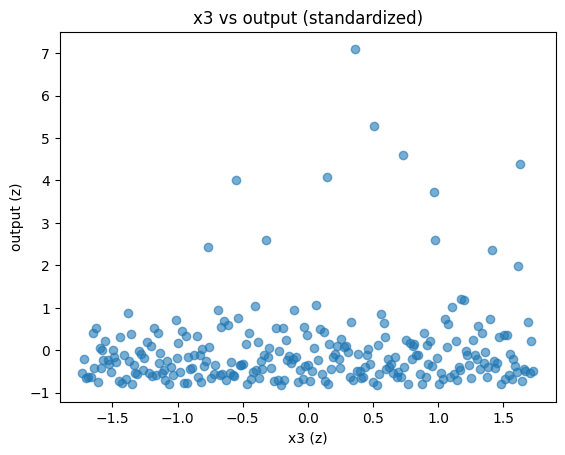

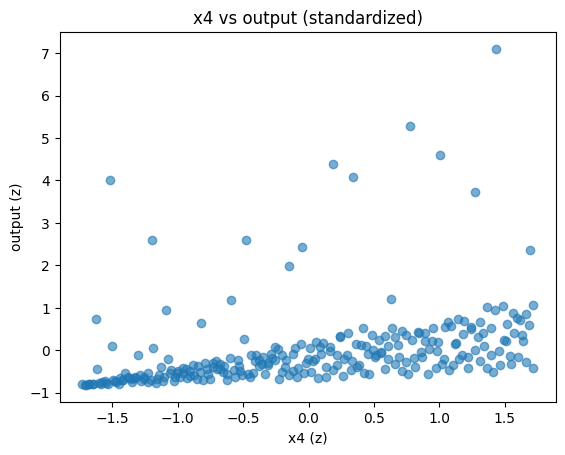

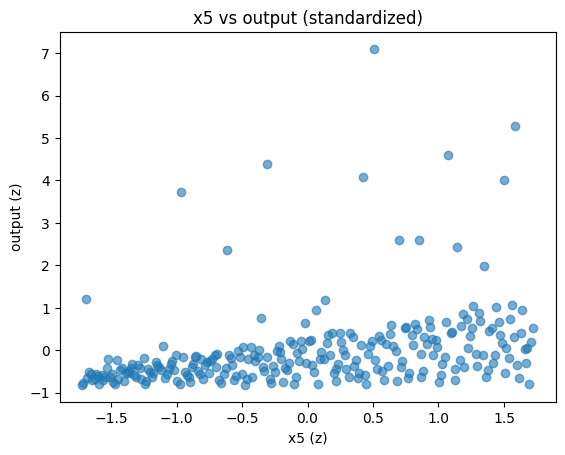

In [51]:


# assuming Xz and yz as standardized inputs/outputs
df_all = Xz.copy()
df_all['output'] = yz
print(df_all.corr()['output'].sort_values(ascending=False))

for c in Xz.columns:
    plt.figure()
    plt.scatter(Xz[c], yz, alpha=0.6)
    plt.xlabel(f"{c} (z)")
    plt.ylabel("output (z)")
    plt.title(f"{c} vs output (standardized)")
    plt.show()